# Bagging Ensemble Demo on Noisy Synthetic Data

**Klasifikatori:**
1. **Decision Trees (DT)**
2. **Random Forest (RF)**

Synth dataset docs: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html



## 1. Priprema dataseta

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
import seaborn as sns
from sklearn.tree import plot_tree
import itertools


In [2]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=3, flip_y=0.2, class_sep=0.7, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


df = pd.DataFrame(X, columns=[f"F{i}" for i in range(X.shape[1])])
df["label"] = y

#sns.pairplot(df, hue="label", corner=True, palette="coolwarm")
#plt.suptitle("Pairwise Feature Scatterplots", y=1.02)
#plt.show()


## 2. Usporedba DT vs Bagging DT


In [3]:
def evaluate_model_cv(name, model, X, y):
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"{name:20s} Mean Acc: {scores.mean():.3f} | Std: {scores.std():.3f}")
    return scores


Classification Report - DT:

              precision    recall  f1-score   support

     Class 0       0.70      0.64      0.67       147
     Class 1       0.68      0.74      0.71       153

    accuracy                           0.69       300
   macro avg       0.69      0.69      0.69       300
weighted avg       0.69      0.69      0.69       300



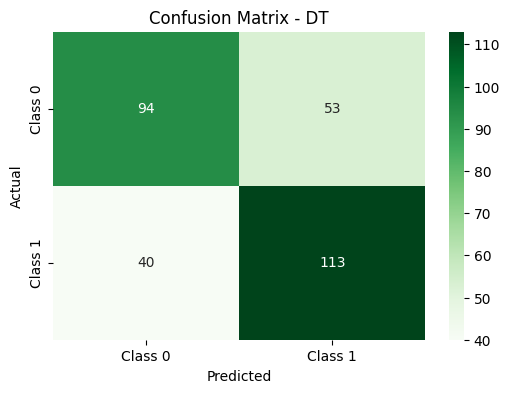

Classification Report - Bagging DT:

              precision    recall  f1-score   support

     Class 0       0.74      0.73      0.74       147
     Class 1       0.74      0.76      0.75       153

    accuracy                           0.74       300
   macro avg       0.74      0.74      0.74       300
weighted avg       0.74      0.74      0.74       300



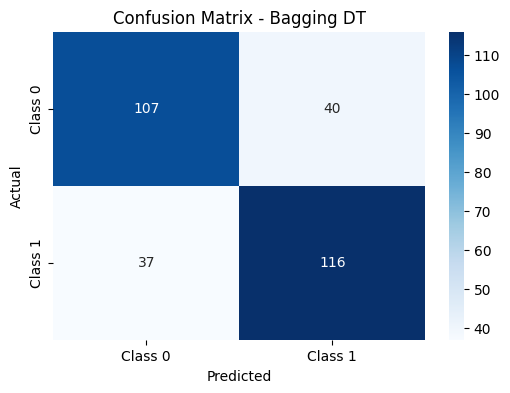

In [4]:
#70-30 split
simple_model = DecisionTreeClassifier(max_depth=5, random_state=42)
bag = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5), n_estimators=100, random_state=42)


simple_model.fit(X_train, y_train)
bag.fit(X_train, y_train)

y_pred_simple = simple_model.predict(X_test)
y_pred_bag = bag.predict(X_test)

class_names = [f"Class {i}" for i in np.unique(y)]

print("Classification Report - DT:\n")
print(classification_report(y_test, y_pred_simple, target_names=class_names))
cm = confusion_matrix(y_test, y_pred_simple)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Greens", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DT")
plt.show()

print("Classification Report - Bagging DT:\n")
print(classification_report(y_test, y_pred_bag, target_names=class_names))
cm = confusion_matrix(y_test, y_pred_bag)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Bagging DT")
plt.show()


Decision Tree        Mean Acc: 0.679 | Std: 0.023
Bagging (DT)         Mean Acc: 0.769 | Std: 0.010


C:\Users\Nikolina\AppData\Local\Temp\ipykernel_24020\2266919068.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys(), showmeans=True)


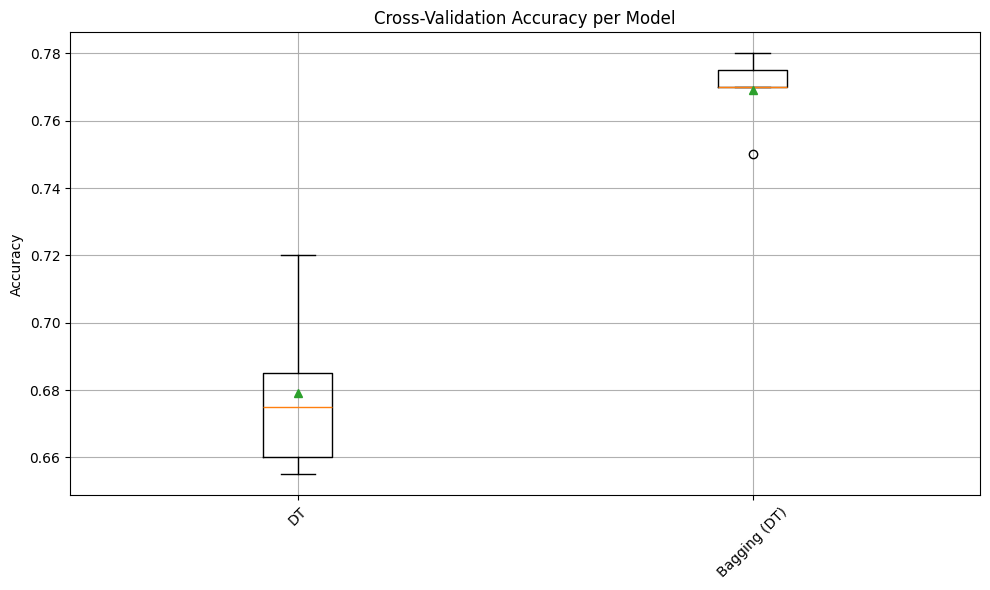

In [5]:
# CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
cv_results["DT"] = evaluate_model_cv("Decision Tree", simple_model, X, y)
cv_results["Bagging (DT)"] = evaluate_model_cv("Bagging (DT)", bag, X, y)

plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), showmeans=True)
plt.title("Cross-Validation Accuracy per Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Random Forest





Classification Report - RF:
              precision    recall  f1-score   support

     Class 0       0.75      0.73      0.74       147
     Class 1       0.75      0.76      0.76       153

    accuracy                           0.75       300
   macro avg       0.75      0.75      0.75       300
weighted avg       0.75      0.75      0.75       300



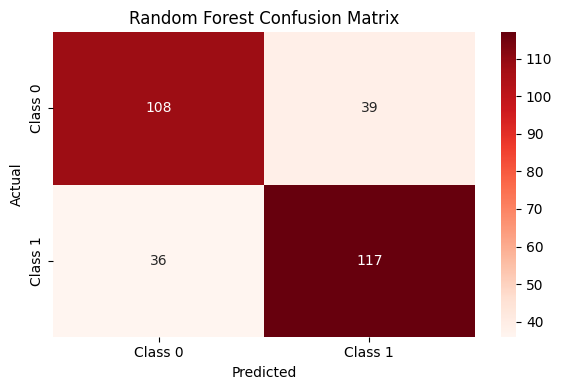

In [6]:
# 70-30 split
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

class_names = [f"Class {i}" for i in np.unique(y)]

print("\nClassification Report - RF:")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Reds", fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

RF                   Mean Acc: 0.785 | Std: 0.013


C:\Users\Nikolina\AppData\Local\Temp\ipykernel_24020\4228636989.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys(), showmeans=True)


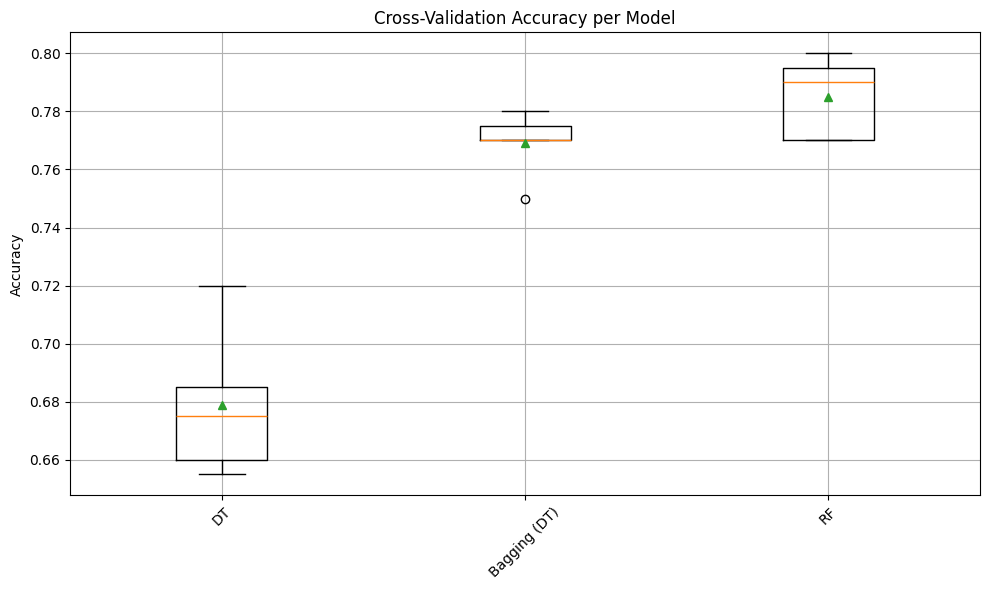

In [7]:
# CV
cv_results["RF"] = evaluate_model_cv("RF", rf, X, y)

plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), showmeans=True)
plt.title("Cross-Validation Accuracy per Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()




## 4. XAI

### A. Feature importance
- ugrađena funkcionalnosti, koliko često se neki feat. koristi za split




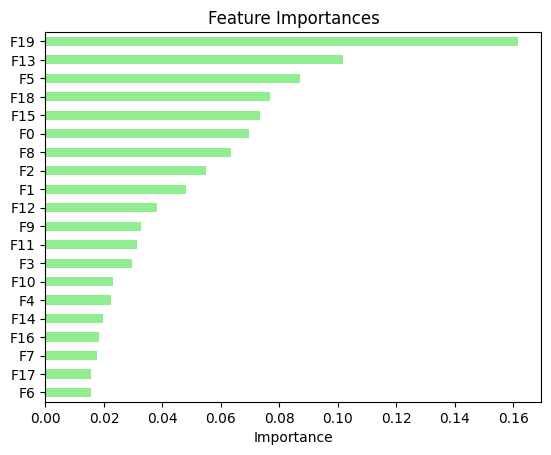

In [8]:
feature_names = [f"F{i}" for i in range(X_train.shape[1])]
feat_imp = pd.Series(rf.feature_importances_, index=feature_names)
feat_imp.sort_values().plot(kind='barh', color='lightgreen')
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.show()

### B. **Permutation importance**
- koliko degradira perf. ako se vrijednost neke značajke nasumično shufflea

C:\Users\Nikolina\AppData\Local\Temp\ipykernel_24020\1336037320.py:49: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


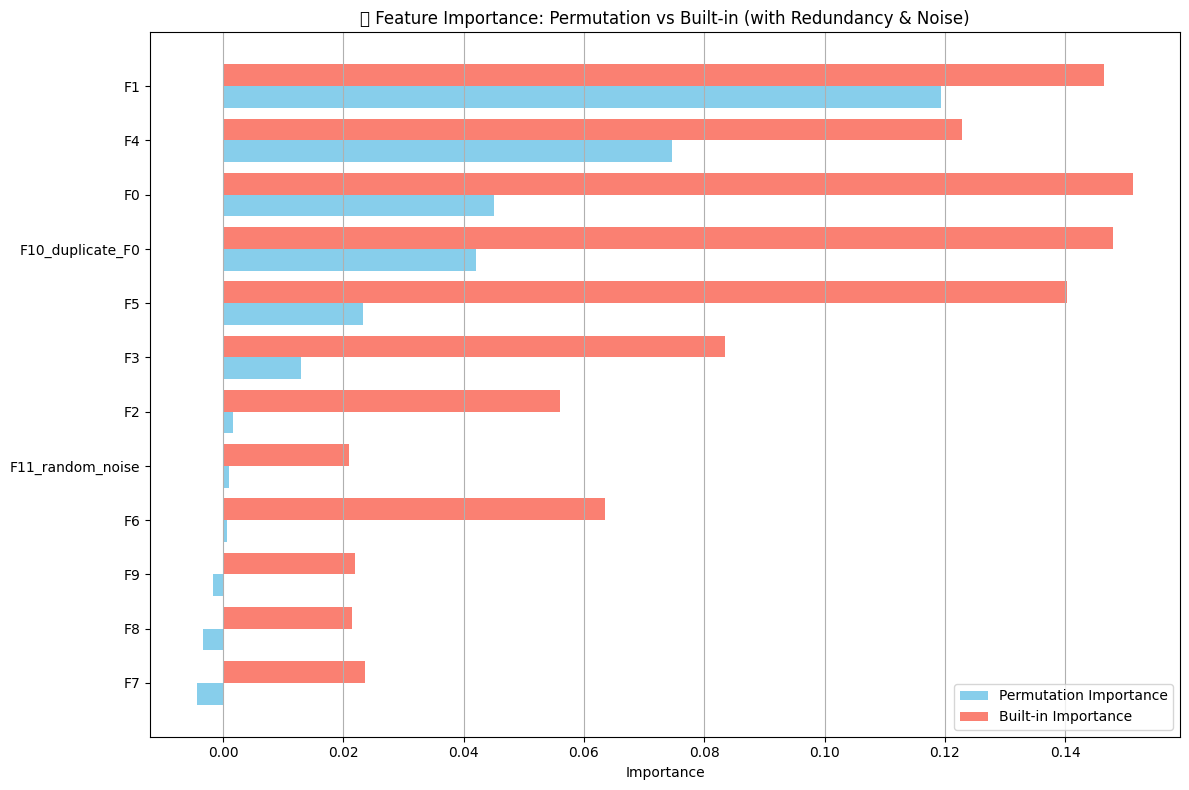

In [9]:
from sklearn.inspection import permutation_importance

# novi, malo "potrgani" dataset s redundancy (F10 kopija F0) i noise (F11)
X_pm, y_pm = make_classification(n_samples=1000, n_features=10, n_informative=5,
                                 n_redundant=2, random_state=42, shuffle=False)

feature_names_pm = [f"F{i}" for i in range(X_pm.shape[1])]
X_pm = pd.DataFrame(X_pm, columns=feature_names_pm)

X_pm["F10_duplicate_F0"] = X_pm["F0"]
X_pm["F11_random_noise"] = np.random.rand(len(X_pm))


feature_names_pm = X_pm.columns.tolist()

X_train_pm, X_test_pm, y_train_pm, y_test_pm = train_test_split(X_pm, y_pm, test_size=0.3, random_state=42)

rf_pm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pm.fit(X_train_pm, y_train_pm)

builtin_importances = rf_pm.feature_importances_

perm_result = permutation_importance(rf_pm, X_test_pm, y_test_pm,
                                     n_repeats=10, random_state=42, scoring='accuracy')
perm_importances = perm_result.importances_mean

importance_df = pd.DataFrame({
    'Feature': feature_names_pm,
    'Built-in Importance': builtin_importances,
    'Permutation Importance': perm_importances
}).sort_values(by='Permutation Importance', ascending=False)


importance_df_sorted = importance_df.sort_values(by='Permutation Importance', ascending=True)
plt.figure(figsize=(12, 8))
bar_width = 0.4
indices = np.arange(len(importance_df_sorted))

plt.barh(indices, importance_df_sorted['Permutation Importance'], height=bar_width,
         label='Permutation Importance', color='skyblue')
plt.barh(indices + bar_width, importance_df_sorted['Built-in Importance'], height=bar_width,
         label='Built-in Importance', color='salmon')

plt.yticks(indices + bar_width / 2, importance_df_sorted['Feature'])
plt.xlabel("Importance")
plt.title("🔍 Feature Importance: Permutation vs Built-in (with Redundancy & Noise)")
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


### 2. Shapley values

**A. GLOBALNO OBJAŠNJENJE:**

**SHAP Bar Plot** – prikazuje prosječnu važnost (doprinos) svake značajke kroz sve predikcije
**SHAP Beeswarm Plot** – prikazuje distribuciju SHAP vrijednosti za svaku značajku kroz sve uzorke — i veličinu i smjer utjecaja (povećava ili smanjuje predikciju)

**B. LOKALNO OBJAŠNJENJE**

**SHAP Waterfall Plot** – prikazuje kako je svaka značajka pomaknula predikciju gore ili dolje u odnosu na baznu vrijednost
**SHAP Force Plot** – prikazuje isto kao Waterfall plot, ali kompaktnije i interaktivno

C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap_values.values.shape: (300, 20, 2)


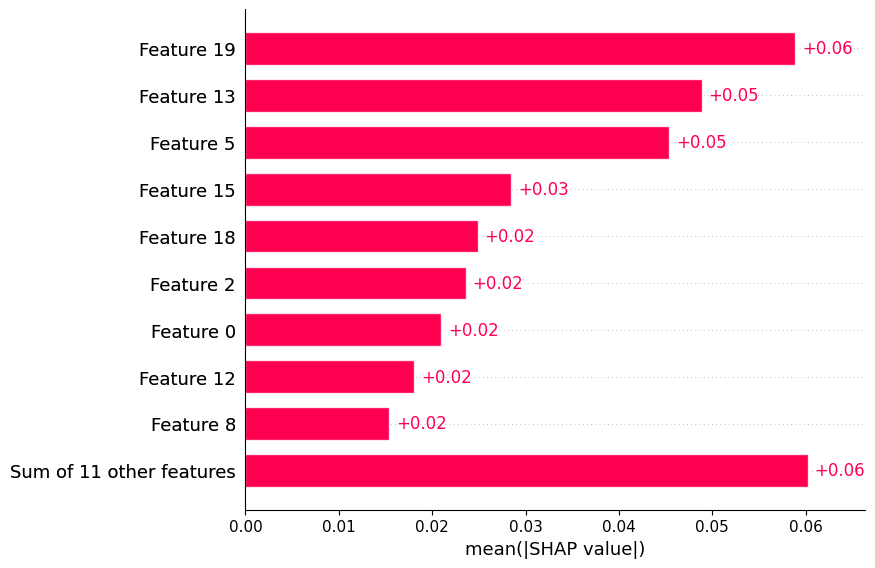

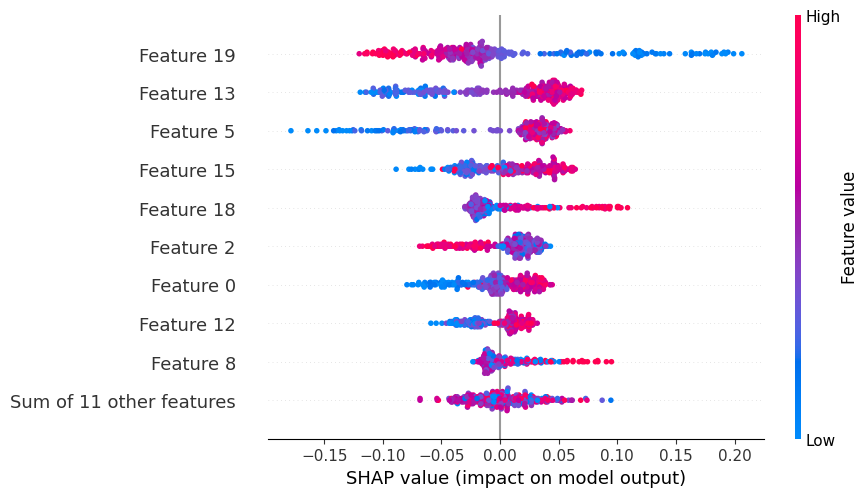

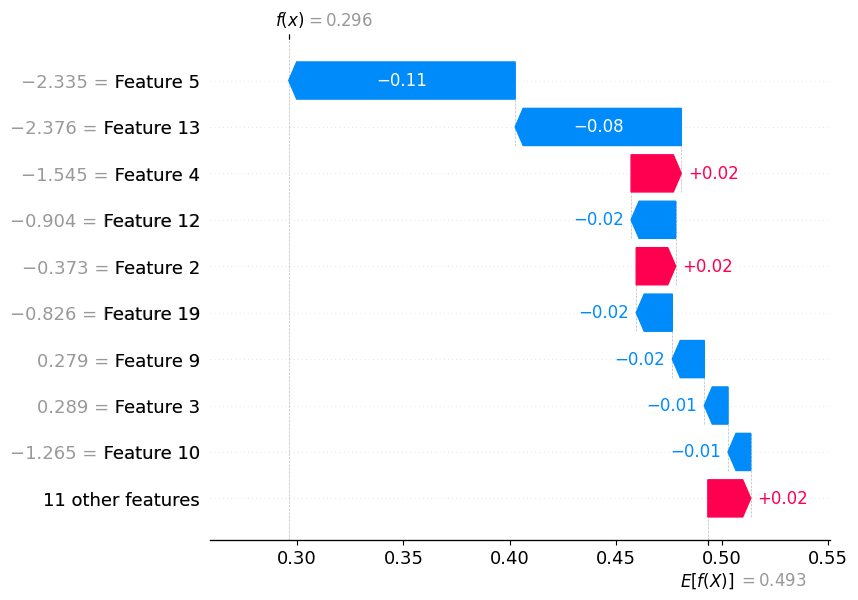

<Figure size 640x480 with 0 Axes>

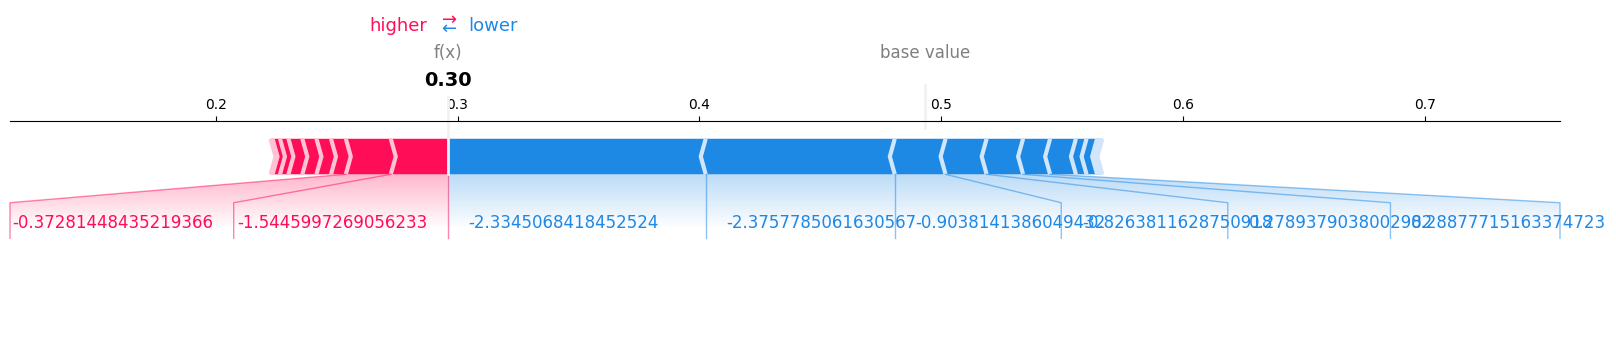

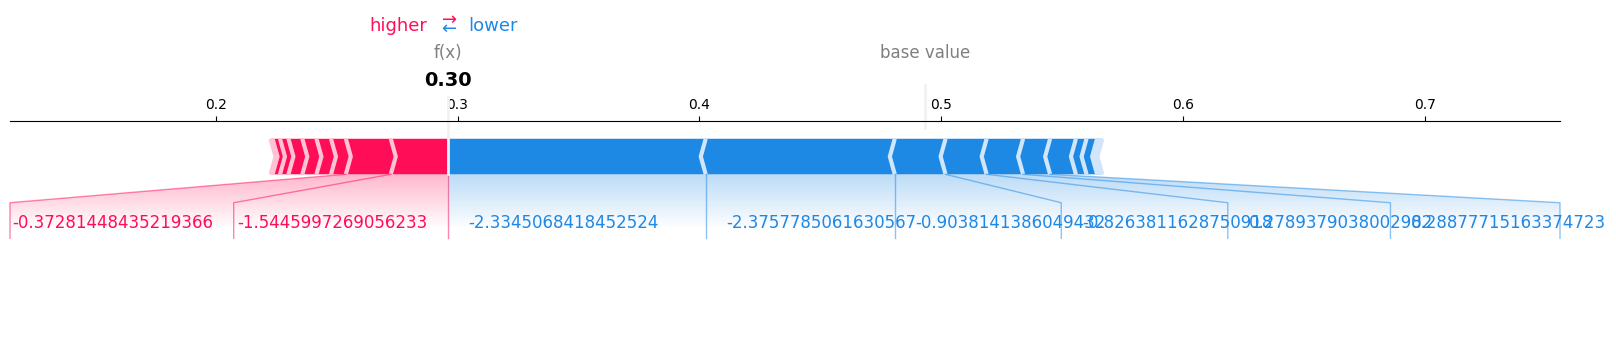

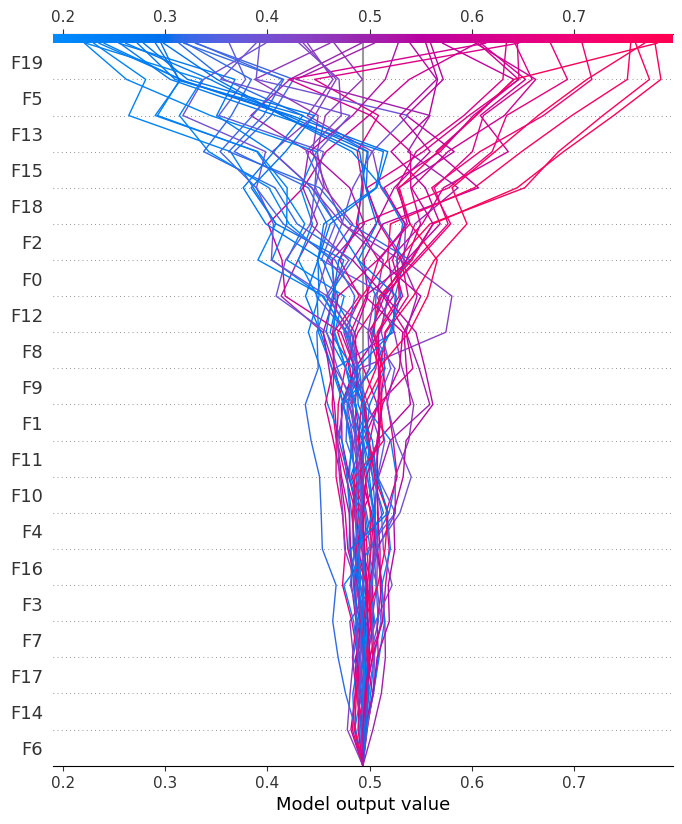

In [10]:
import shap

shap.initjs()
#vraćamo se na početni dataset
explainer = shap.Explainer(rf, X_train) # will automatically select TreeExplainer for rf model
shap_values = explainer(X_test, check_additivity=False)

print("shap_values.values.shape:", shap_values.values.shape)

num_classes = shap_values.values.shape[2]

# for entire class 1 (assuming 1 = positive class)
shap.plots.bar(shap_values[..., 1])
shap.plots.beeswarm(shap_values[..., 1])

#for one prediction
shap_values_class = shap_values[..., 1]
shap.plots.waterfall(shap_values[1, :, 1])
plt.figure()
shap.plots.force(shap_values_class[1], matplotlib=True)
plt.show()

shap.initjs()
shap.plots.force(shap_values_class[1], matplotlib=True)


#decision plot - convert X_test to DataFrame (if not already)
if not isinstance(X_test, pd.DataFrame):
    feature_names = [f"F{i}" for i in range(X.shape[1])]
    X_test = pd.DataFrame(X_test, columns=feature_names)

shap.decision_plot(
    explainer.expected_value[1],           # base value for class 1
    shap_values.values[:50, :, 1],          # SHAP values for class 1
    X_test.iloc[:50]                        # features for those same samples
)


#### Feature importance vs. SHAP bar plot

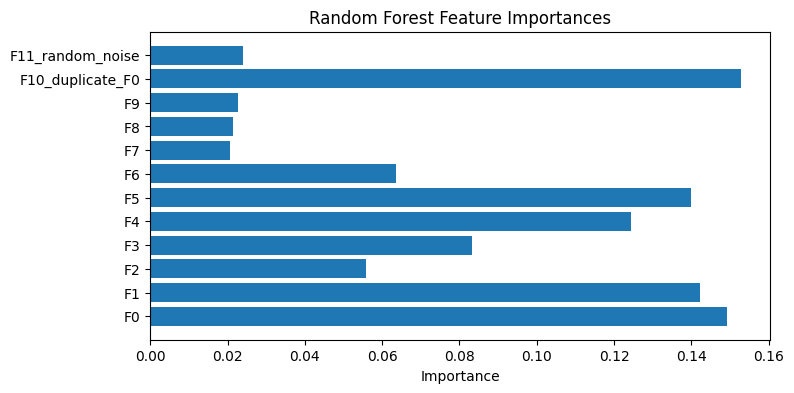

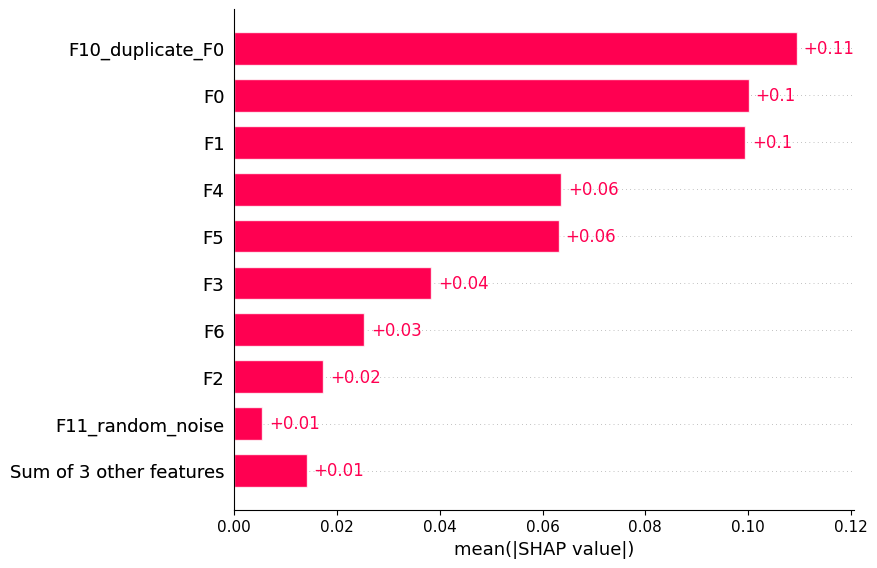

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Create synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5,
                           n_redundant=2, random_state=42, shuffle=False)

feature_names = [f"F{i}" for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)

# 2. Inject redundancy + noise
X["F10_duplicate_F0"] = X["F0"]                    # Perfect duplicate of F0
X["F11_random_noise"] = np.random.rand(len(X))    # Pure noise


# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 4. Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 5. Plot built-in Random Forest feature importances
importances = rf.feature_importances_
plt.figure(figsize=(8, 4))
plt.barh(X.columns, importances)
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

# 6. Use SHAP for explanation
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)

# 7. SHAP bar plot (mean absolute SHAP values)
shap.plots.bar(shap_values[..., 0])
